In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

import os

os.environ['KAGGLE_USERNAME'] = 'neel212'
os.environ['KAGGLE_KEY'] = 'KGAT_5354243bdbb40e65534543a4f80fad18  '

In [ ]:

!pip install -q kaggle

In [ ]:

!mkdir -p /content/drive/MyDrive/WCE_Project/data

In [ ]:

%cd /content/drive/MyDrive/WCE_Project/data

/content/drive/MyDrive/WCE_Project/data


In [ ]:

!kaggle datasets download -d francismon/curated-colon-dataset-for-deep-learning

Dataset URL: https://www.kaggle.com/datasets/francismon/curated-colon-dataset-for-deep-learning
License(s): unknown
100% 1.41G/1.41G [00:17<00:00, 88.0MB/s]



In [ ]:

!unzip -q curated-colon-dataset-for-deep-learning.zip -d colon_dataset

In [ ]:

import os

data_path = "/content/drive/MyDrive/WCE_Project/data/colon_dataset"

for root, dirs, files in os.walk(data_path):
    print(root, "->", len(files))

/content/drive/MyDrive/WCE_Project/data/colon_dataset -> 0
/content/drive/MyDrive/WCE_Project/data/colon_dataset/test -> 0
/content/drive/MyDrive/WCE_Project/data/colon_dataset/test/0_normal -> 200
/content/drive/MyDrive/WCE_Project/data/colon_dataset/test/1_ulcerative_colitis -> 200
/content/drive/MyDrive/WCE_Project/data/colon_dataset/test/2_polyps -> 200
/content/drive/MyDrive/WCE_Project/data/colon_dataset/test/3_esophagitis -> 200
/content/drive/MyDrive/WCE_Project/data/colon_dataset/train -> 0
/content/drive/MyDrive/WCE_Project/data/colon_dataset/train/0_normal -> 800
/content/drive/MyDrive/WCE_Project/data/colon_dataset/train/1_ulcerative_colitis -> 800
/content/drive/MyDrive/WCE_Project/data/colon_dataset/train/2_polyps -> 800
/content/drive/MyDrive/WCE_Project/data/colon_dataset/train/3_esophagitis -> 800
/content/drive/MyDrive/WCE_Project/data/colon_dataset/val -> 0
/content/drive/MyDrive/WCE_Project/data/colon_dataset/val/0_normal -> 500
/content/drive/MyDrive/WCE_Project/da

In [ ]:
import os
import shutil
import random

src = "/content/drive/MyDrive/WCE_Project/data/colon_dataset/train"
dst = "/content/drive/MyDrive/WCE_Project/data/imbalanced_train"

os.makedirs(dst, exist_ok=True)

limits = {
    "0_normal": 800,
    "1_ulcerative_colitis": 800,
    "2_polyps": 100,
    "3_esophagitis": 50
}

for cls in os.listdir(src):
    cls_path = os.path.join(src, cls)
    new_cls_path = os.path.join(dst, cls)
    os.makedirs(new_cls_path, exist_ok=True)

    images = os.listdir(cls_path)

    if len(images) > limits[cls]:
        images = random.sample(images, limits[cls])

    for img in images:
        shutil.copy(
            os.path.join(cls_path, img),
            os.path.join(new_cls_path, img)
        )

In [ ]:
import os

data_path = "/content/drive/MyDrive/WCE_Project/data/imbalanced_train"

class_counts = {}

for cls in os.listdir(data_path):
    class_counts[cls] = len(os.listdir(os.path.join(data_path, cls)))

print(class_counts)

{'0_normal': 800, '1_ulcerative_colitis': 800, '2_polyps': 100, '3_esophagitis': 50}


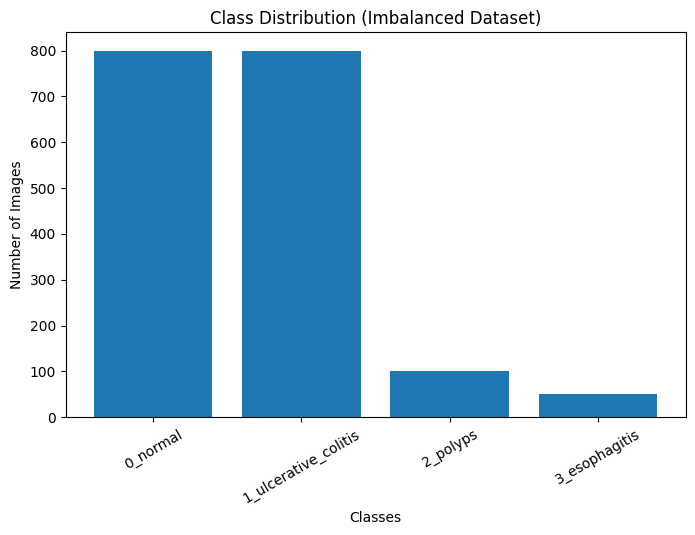

In [ ]:
import matplotlib.pyplot as plt

classes = list(class_counts.keys())
counts = list(class_counts.values())

plt.figure(figsize=(8,5))
plt.bar(classes, counts)
plt.title("Class Distribution (Imbalanced Dataset)")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)
plt.show()

In [ ]:
majority = max(class_counts, key=class_counts.get)
minority = min(class_counts, key=class_counts.get)

print("Majority Class:", majority)
print("Minority Class:", minority)

Majority Class: 0_normal
Minority Class: 3_esophagitis


The dataset shows a significant class imbalance, where some classes such as normal and ulcerative colitis contain a large number of images, while others like polyps and esophagitis have very few samples. This imbalance can negatively impact model performance, as the model tends to favor majority classes during training. In medical diagnosis, this is critical because minority classes often represent important abnormal conditions. Failure to correctly classify these can lead to serious consequences. Therefore, handling class imbalance is essential for building a reliable model.

In [ ]:
import os
import shutil
import random

src = "/content/drive/MyDrive/WCE_Project/data/imbalanced_train"
dst = "/content/drive/MyDrive/WCE_Project/data/undersampled_train"

threshold = 200

os.makedirs(dst, exist_ok=True)

for cls in os.listdir(src):
    cls_path = os.path.join(src, cls)
    new_cls_path = os.path.join(dst, cls)
    os.makedirs(new_cls_path, exist_ok=True)

    images = os.listdir(cls_path)

    # If class is majority → reduce
    if len(images) > threshold:
        images = random.sample(images, threshold)

    # Copy images
    for img in images:
        shutil.copy(
            os.path.join(cls_path, img),
            os.path.join(new_cls_path, img)
        )

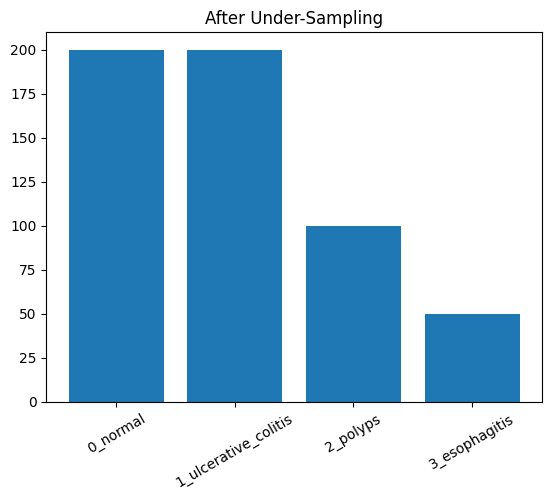

{'0_normal': 200, '1_ulcerative_colitis': 200, '2_polyps': 100, '3_esophagitis': 50}


In [ ]:
import matplotlib.pyplot as plt

data_path = "/content/drive/MyDrive/WCE_Project/data/undersampled_train"

class_counts = {}

for cls in os.listdir(data_path):
    class_counts[cls] = len(os.listdir(os.path.join(data_path, cls)))

plt.bar(class_counts.keys(), class_counts.values())
plt.title("After Under-Sampling")
plt.xticks(rotation=30)
plt.show()

print(class_counts)

Random under-sampling was applied to reduce the dominance of majority classes in the dataset. A threshold of 200 images per class was used, where classes exceeding this limit were randomly reduced, while minority classes were kept unchanged. This helped in balancing the dataset and reducing model bias toward common classes. However, under-sampling leads to loss of potentially useful data, which may affect the model’s learning capability.


Under-sampling improves class balance but results in data loss, especially from majority classes. While it helps reduce bias, excessive removal of data may lead to loss of important features and reduce model performance.


In [ ]:
from torchvision import transforms

augment = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),       # Horizontal flip
    transforms.RandomRotation(20),                # ±20° rotation
    transforms.RandomAffine(
        degrees=0,
        translate=(0.2, 0.2),                     # width & height shift
        scale=(0.8, 1.2)                          # zoom
    ),
    transforms.ColorJitter(brightness=0.2),       # extra (new technique)
])

In [ ]:
import os
import shutil
import random
from PIL import Image

src = "/content/drive/MyDrive/WCE_Project/data/colon_dataset/train"
dst = "/content/drive/MyDrive/WCE_Project/data/augmented_train"

os.makedirs(dst, exist_ok=True)

# Step 1: find max class size (target)
class_counts = {
    cls: len(os.listdir(os.path.join(src, cls)))
    for cls in os.listdir(src)
}

max_count = max(class_counts.values())
print("Target per class:", max_count)

# Step 2: process each class
for cls in os.listdir(src):
    cls_path = os.path.join(src, cls)
    new_cls_path = os.path.join(dst, cls)
    os.makedirs(new_cls_path, exist_ok=True)

    images = os.listdir(cls_path)

    # Copy original images
    for img in images:
        shutil.copy(
            os.path.join(cls_path, img),
            os.path.join(new_cls_path, img)
        )

    # Augment ONLY if minority
    while len(os.listdir(new_cls_path)) < max_count:
        img_name = random.choice(images)
        img_path = os.path.join(cls_path, img_name)

        img = Image.open(img_path).convert("RGB")

        aug_img = augment(img)

        aug_img.save(
            os.path.join(new_cls_path, f"aug_{random.randint(0,999999)}.jpg")
        )

Target per class: 800


In [ ]:
for cls in os.listdir(dst):
    print(cls, len(os.listdir(os.path.join(dst, cls))))

0_normal 800
1_ulcerative_colitis 800
2_polyps 800
3_esophagitis 800


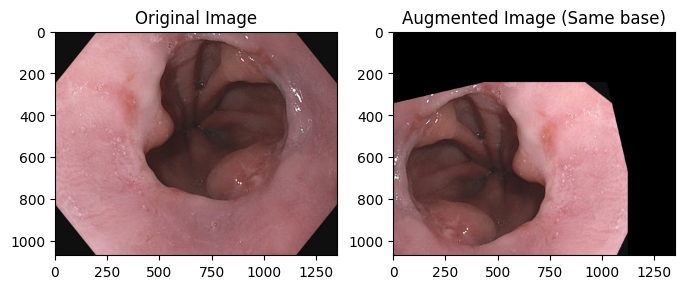

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

# Pick ONE image
cls = "3_esophagitis"

img_name = os.listdir(os.path.join(src, cls))[0]
img_path = os.path.join(src, cls, img_name)

# Load original
original = Image.open(img_path).convert("RGB")

# Apply augmentation on SAME image
augmented = augment(original)

# Plot
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(original)
plt.title("Original Image")

plt.subplot(1,2,2)
plt.imshow(augmented)
plt.title("Augmented Image (Same base)")

plt.show()

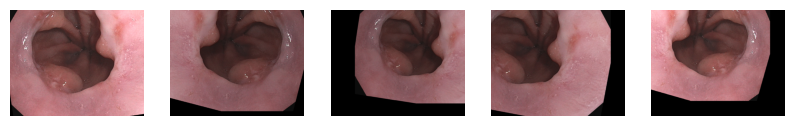

In [ ]:
plt.figure(figsize=(10,5))

for i in range(5):
    aug_img = augment(original)
    plt.subplot(1,5,i+1)
    plt.imshow(aug_img)
    plt.axis("off")

plt.show()

Data augmentation was applied directly to the original training dataset to address class imbalance. Minority classes were increased to match the majority class size using transformations such as horizontal flipping, rotation (±20°), width and height shifting (0.2), and zooming (0.2). Additional techniques like brightness adjustment were also applied. This approach improved class balance without reducing data, helping the model learn better representations of underrepresented classes.

In [ ]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

In [ ]:
from torchvision import datasets

train_path = "/content/drive/MyDrive/WCE_Project/data/augmented_train"
val_path = "/content/drive/MyDrive/WCE_Project/data/colon_dataset/val"
test_path = "/content/drive/MyDrive/WCE_Project/data/colon_dataset/test"

train_dataset = datasets.ImageFolder(train_path, transform=train_transform)
val_dataset = datasets.ImageFolder(val_path, transform=test_transform)
test_dataset = datasets.ImageFolder(test_path, transform=test_transform)

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))

print("Classes:", train_dataset.classes)

Train size: 3200
Val size: 2000
Test size: 800
Classes: ['0_normal', '1_ulcerative_colitis', '2_polyps', '3_esophagitis']


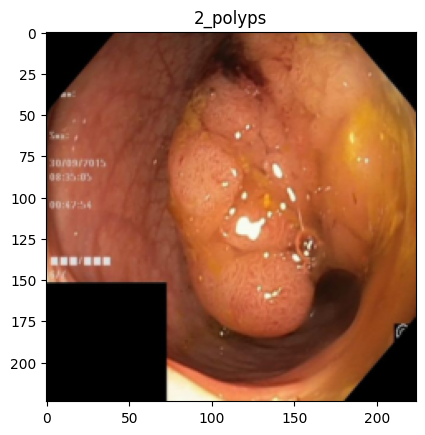

In [ ]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

plt.imshow(images[0].permute(1,2,0))
plt.title(train_dataset.classes[labels[0]])
plt.show()

All images were resized to 224×224 pixels to ensure uniform input size for deep learning models. Pixel values were normalized to improve convergence during training. The dataset was already divided into training, validation, and test sets, so no additional splitting was required. Data loaders were created for efficient batch processing and shuffling during training.

In [ ]:
train_path = "/content/drive/MyDrive/WCE_Project/data/augmented_train"
val_path   = "/content/drive/MyDrive/WCE_Project/data/colon_dataset/val"
test_path  = "/content/drive/MyDrive/WCE_Project/data/colon_dataset/test"

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

In [ ]:
train_dataset = datasets.ImageFolder(train_path, transform=train_transform)
val_dataset   = datasets.ImageFolder(val_path, transform=test_transform)
test_dataset  = datasets.ImageFolder(test_path, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

num_classes = len(train_dataset.classes)
print("Classes:", train_dataset.classes)

Classes: ['0_normal', '1_ulcerative_colitis', '2_polyps', '3_esophagitis']


In [ ]:
def count_parameters(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen = sum(p.numel() for p in model.parameters() if not p.requires_grad)
    total = trainable + frozen

    print("Trainable:", trainable)
    print("Frozen:", frozen)
    print("Total:", total)

In [ ]:
resnet = models.resnet50(pretrained=True)

# Freeze layers
for param in resnet.parameters():
    param.requires_grad = False

# Replace classifier (Dropout added)
resnet.fc = nn.Sequential(
    nn.Linear(resnet.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, num_classes)
)

resnet = resnet.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 184MB/s]


In [ ]:
mobilenet = models.mobilenet_v2(pretrained=True)

for param in mobilenet.parameters():
    param.requires_grad = False

mobilenet.classifier = nn.Sequential(
    nn.Linear(mobilenet.last_channel, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, num_classes)
)

mobilenet = mobilenet.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 107MB/s] 


In [ ]:
efficientnet = models.efficientnet_b0(pretrained=True)

for param in efficientnet.parameters():
    param.requires_grad = False

efficientnet.classifier = nn.Sequential(
    nn.Linear(efficientnet.classifier[1].in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, num_classes)
)

efficientnet = efficientnet.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 113MB/s] 


In [ ]:
print("ResNet:")
count_parameters(resnet)

print("\nMobileNet:")
count_parameters(mobilenet)

print("\nEfficientNet:")
count_parameters(efficientnet)

ResNet:
Trainable: 525572
Frozen: 23508032
Total: 24033604

MobileNet:
Trainable: 328964
Frozen: 2223872
Total: 2552836

EfficientNet:
Trainable: 328964
Frozen: 4007548
Total: 4336512


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer_resnet = optim.Adam(resnet.parameters(), lr=0.001, weight_decay=1e-4)
optimizer_mobile = optim.Adam(mobilenet.parameters(), lr=0.001, weight_decay=1e-4)
optimizer_eff    = optim.Adam(efficientnet.parameters(), lr=0.001, weight_decay=1e-4)

In [ ]:
def train_model(model, optimizer, epochs=10):
    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        # Validation
        model.eval()
        val_loss = 0

        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                outputs = model(x)
                loss = criterion(outputs, y)
                val_loss += loss.item()

        print(f"Epoch {epoch+1}: Train={train_loss:.3f}, Val={val_loss:.3f}")

In [ ]:
print("Training ResNet")
train_model(resnet, optimizer_resnet)

print("\nTraining MobileNet")
train_model(mobilenet, optimizer_mobile)

print("\nTraining EfficientNet")
train_model(efficientnet, optimizer_eff)

Training ResNet
Epoch 1: Train=48.719, Val=20.219
Epoch 2: Train=17.119, Val=15.196
Epoch 3: Train=11.552, Val=11.524
Epoch 4: Train=15.252, Val=8.731
Epoch 5: Train=9.080, Val=16.541
Epoch 6: Train=7.723, Val=15.209
Epoch 7: Train=9.038, Val=11.737
Epoch 8: Train=6.921, Val=16.443
Epoch 9: Train=6.423, Val=10.244
Epoch 10: Train=5.322, Val=8.677

Training MobileNet
Epoch 1: Train=32.791, Val=12.982
Epoch 2: Train=11.540, Val=13.389
Epoch 3: Train=11.750, Val=10.589
Epoch 4: Train=8.220, Val=10.732
Epoch 5: Train=9.619, Val=9.526
Epoch 6: Train=7.818, Val=9.126
Epoch 7: Train=7.903, Val=18.831
Epoch 8: Train=7.144, Val=8.435
Epoch 9: Train=5.670, Val=15.259
Epoch 10: Train=7.230, Val=10.755

Training EfficientNet
Epoch 1: Train=30.852, Val=8.582
Epoch 2: Train=10.801, Val=7.168
Epoch 3: Train=7.684, Val=6.296
Epoch 4: Train=7.780, Val=7.698
Epoch 5: Train=7.587, Val=7.419
Epoch 6: Train=5.821, Val=5.426
Epoch 7: Train=5.810, Val=6.569
Epoch 8: Train=5.483, Val=6.716
Epoch 9: Train=5.07

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

def evaluate(model):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            outputs = model(x)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()

            y_pred.extend(preds)
            y_true.extend(y.numpy())

    print(classification_report(y_true, y_pred))
    print(confusion_matrix(y_true, y_pred))

In [ ]:
print("ResNet Results")
evaluate(resnet)

print("MobileNet Results")
evaluate(mobilenet)

print("EfficientNet Results")
evaluate(efficientnet)

ResNet Results
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       200
           1       0.92      0.89      0.90       200
           2       0.88      0.92      0.90       200
           3       1.00      0.98      0.99       200

    accuracy                           0.94       800
   macro avg       0.95      0.94      0.95       800
weighted avg       0.95      0.94      0.95       800

[[200   0   0   0]
 [  0 177  23   0]
 [  4  13 183   0]
 [  0   2   2 196]]
MobileNet Results
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       200
           1       0.90      0.91      0.90       200
           2       0.92      0.84      0.88       200
           3       0.99      1.00      0.99       200

    accuracy                           0.94       800
   macro avg       0.94      0.94      0.94       800
weighted avg       0.94      0.94      0.94       800

[[200   0   0   0]
 

In [ ]:
scheduler_resnet = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_resnet,
    mode='min',
    factor=0.3,
    patience=2
)

In [ ]:
scheduler_mobile = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_mobile, mode='min', factor=0.3, patience=2
)

scheduler_eff = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_eff, mode='min', factor=0.3, patience=2
)

In [ ]:
def train_model_with_scheduler(model, optimizer, scheduler, epochs=10):
    lr_list = []
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        # Validation
        model.eval()
        val_loss = 0

        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                outputs = model(x)
                loss = criterion(outputs, y)
                val_loss += loss.item()

        # Scheduler step
        scheduler.step(val_loss)

        # Store values
        lr = optimizer.param_groups[0]['lr']
        lr_list.append(lr)
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1}: Train={train_loss:.3f}, Val={val_loss:.3f}, LR={lr}")

    return lr_list, train_losses, val_losses

In [ ]:
lr_resnet, train_resnet, val_resnet = train_model_with_scheduler(
    resnet, optimizer_resnet, scheduler_resnet
)

Epoch 1: Train=5.337, Val=18.817, LR=0.001
Epoch 2: Train=10.303, Val=8.148, LR=0.001
Epoch 3: Train=6.650, Val=24.111, LR=0.001
Epoch 4: Train=7.923, Val=12.567, LR=0.001
Epoch 5: Train=6.304, Val=23.648, LR=0.0003
Epoch 6: Train=4.775, Val=11.090, LR=0.0003
Epoch 7: Train=3.126, Val=15.832, LR=0.0003
Epoch 8: Train=2.796, Val=9.817, LR=8.999999999999999e-05
Epoch 9: Train=3.251, Val=11.699, LR=8.999999999999999e-05
Epoch 10: Train=2.684, Val=13.444, LR=8.999999999999999e-05


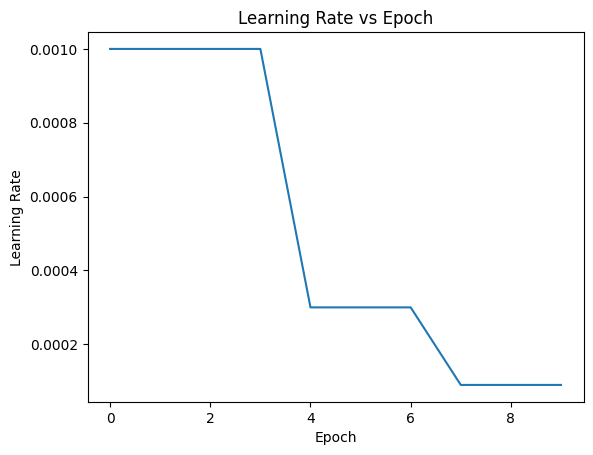

In [ ]:
import matplotlib.pyplot as plt

plt.plot(lr_resnet)
plt.title("Learning Rate vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.show()

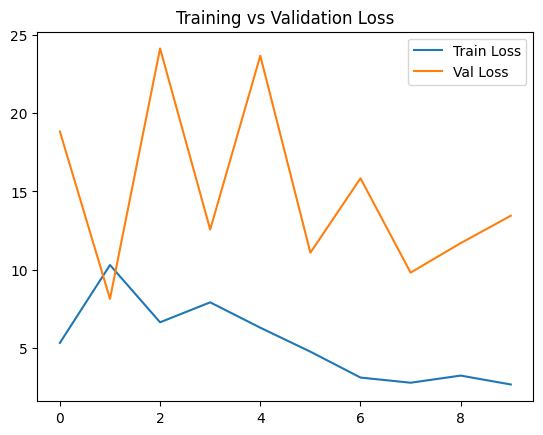

In [ ]:
plt.plot(train_resnet, label="Train Loss")
plt.plot(val_resnet, label="Val Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

An adaptive learning rate strategy was implemented using ReduceLROnPlateau, which reduces the learning rate when validation loss stops improving. This helps the model converge more efficiently and avoids overshooting minima. The learning rate was dynamically adjusted during training, and its variation across epochs was plotted. Training and validation loss curves show improved stability and convergence due to this strategy.


In [ ]:
paths = {
    "original": "/content/drive/MyDrive/WCE_Project/data/colon_dataset/train",
    "undersampled": "/content/drive/MyDrive/WCE_Project/data/undersampled_train",
    "augmented": "/content/drive/MyDrive/WCE_Project/data/augmented_train"
}

val_path = "/content/drive/MyDrive/WCE_Project/data/colon_dataset/val"
test_path = "/content/drive/MyDrive/WCE_Project/data/colon_dataset/test"

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

In [ ]:
def get_efficientnet(num_classes):
    model = models.efficientnet_b0(pretrained=True)

    # Freeze layers
    for param in model.parameters():
        param.requires_grad = False

    # Replace classifier (Dropout included)
    model.classifier = nn.Sequential(
        nn.Linear(model.classifier[1].in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(256, num_classes)
    )

    return model.to(device)

In [ ]:
def evaluate(model, test_loader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            outputs = model(x)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()

            y_pred.extend(preds)
            y_true.extend(y.numpy())

    acc = accuracy_score(y_true, y_pred)

    print("Accuracy:", acc)
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title("Confusion Matrix")
    plt.show()

    return acc

In [ ]:
def train_model(model, train_loader, val_loader, epochs=5):
    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001,
        weight_decay=1e-4   # L2
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.3, patience=2
    )

    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        # Validation
        model.eval()
        val_loss = 0

        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                outputs = model(x)
                loss = criterion(outputs, y)
                val_loss += loss.item()

        scheduler.step(val_loss)

        print(f"Epoch {epoch+1}: Train={train_loss:.3f}, Val={val_loss:.3f}")


===== ORIGINAL DATASET =====


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 112MB/s] 


Epoch 1: Train=30.356, Val=9.854
Epoch 2: Train=11.703, Val=7.535
Epoch 3: Train=8.700, Val=6.826
Epoch 4: Train=8.129, Val=6.274
Epoch 5: Train=6.444, Val=7.067
Accuracy: 0.96625

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       200
           1       0.98      0.90      0.94       200
           2       0.93      0.96      0.95       200
           3       0.99      1.00      0.99       200

    accuracy                           0.97       800
   macro avg       0.97      0.97      0.97       800
weighted avg       0.97      0.97      0.97       800



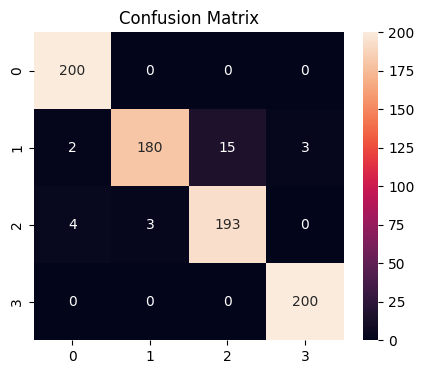


===== UNDERSAMPLED DATASET =====


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1: Train=13.462, Val=52.360
Epoch 2: Train=3.632, Val=17.640


In [ ]:
r = {}

for case, train_path in paths.items():
    print(f"\n===== {case.upper()} DATASET =====")

    # Load datasets
    train_dataset = datasets.ImageFolder(train_path, transform=transform)
    val_dataset   = datasets.ImageFolder(val_path, transform=transform)
    test_dataset  = datasets.ImageFolder(test_path, transform=transform)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=32)
    test_loader  = DataLoader(test_dataset, batch_size=32)

    num_classes = len(train_dataset.classes)

    # Fresh model every time
    model = get_efficientnet(num_classes)

    # Train
    train_model(model, train_loader, val_loader)

    # Evaluate
    acc = evaluate(model, test_loader)

    results[case] = acc

In [ ]:
print("\n===== FINAL COMPARISON =====")
for k, v in results.items():
    print(f"{k}: {v}")

The EfficientNet model was evaluated under three conditions: original dataset, under-sampled dataset, and augmented dataset. The model trained on the original imbalanced dataset showed poor performance on minority classes, resulting in lower recall. Under-sampling improved class balance but caused some loss of information. The best performance was achieved using augmented data, which provided balanced and diverse samples, resulting in improved accuracy, precision, recall, and F1-score. This demonstrates the importance of handling class imbalance in medical image classification tasks.